### 1. Data Loading and Initial Inspection
We will begin by loading the dataset and checking its dimensions and basic properties.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Waste_Management_and_Recycling_India_cleaned.csv'
df = pd.read_csv(file_path)

# Basic inspection
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (850, 13)


,city/district,waste_type,waste_generated_(tons/day),recycling_rate_(%),population_density_(people/km²),municipal_efficiency_score_(1_10),disposal_method,cost_of_waste_management_(₹/ton),awareness_campaigns_count,landfill_name,"landfill_location_(lat,_long)",landfill_capacity_(tons),year
0,Mumbai,Plastic,6610,68,11191,9,Composting,3056,14,Mumbai Landfill,"22.4265, 77.4931",45575,1970
1,Mumbai,Organic,1181,56,11191,5,Composting,2778,12,Mumbai Landfill,"22.4265, 77.4931",45575,1970
2,Mumbai,E-Waste,8162,53,11191,8,Incineration,3390,13,Mumbai Landfill,"22.4265, 77.4931",45575,1970
3,Mumbai,Construction,8929,56,11191,5,Landfill,1498,14,Mumbai Landfill,"22.4265, 77.4931",45575,1970
4,Mumbai,Hazardous,5032,44,11191,7,Recycling,2221,16,Mumbai Landfill,"22.4265, 77.4931",45575,1970


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   city/district                      850 non-null    object
 1   waste_type                         850 non-null    object
 2   waste_generated_(tons/day)         850 non-null    int64 
 3   recycling_rate_(%)                 850 non-null    int64 
 4   population_density_(people/km²)    850 non-null    int64 
 5   municipal_efficiency_score_(1_10)  850 non-null    int64 
 6   disposal_method                    850 non-null    object
 7   cost_of_waste_management_(₹/ton)   850 non-null    int64 
 8   awareness_campaigns_count          850 non-null    int64 
 9   landfill_name                      850 non-null    object
 10  landfill_location_(lat,_long)      850 non-null    object
 11  landfill_capacity_(tons)           850 non-null    int64 
 12  year    

None

### 2. Data Cleaning and Statistical Summary
We will check for duplicates and look at the statistical distribution of the numerical features.

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Descriptive statistics for numerical columns
display(df.describe())

# Unique values for categorical columns to ensure consistency
for col in ['waste_type', 'disposal_method']:
    print(f"Unique values in {col}: {df[col].unique()}")

Number of duplicate rows: 0


,waste_generated_(tons/day),recycling_rate_(%),population_density_(people/km²),municipal_efficiency_score_(1_10),cost_of_waste_management_(₹/ton),awareness_campaigns_count,landfill_capacity_(tons),year
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.0
mean,5262.249412,57.076471,13489.705882,7.400000,2778.458824,9.904706,58934.617647,1970.0
std,2786.984735,16.129994,6631.081494,1.722162,1276.325630,6.070772,19413.627292,0.0
min,511.000000,30.000000,2335.000000,5.000000,503.000000,0.000000,22690.000000,1970.0
25%,2865.750000,43.000000,7927.000000,6.000000,1647.500000,5.000000,45575.000000,1970.0
50%,5283.000000,56.000000,12579.500000,7.000000,2853.000000,10.000000,61038.500000,1970.0
75%,7757.250000,71.000000,19087.000000,9.000000,3855.000000,15.000000,71127.000000,1970.0
max,9980.000000,85.000000,24032.000000,10.000000,4999.000000,20.000000,98646.000000,1970.0


Unique values in waste_type: ['Plastic' 'Organic' 'E-Waste' 'Construction' 'Hazardous']
Unique values in disposal_method: ['Composting' 'Incineration' 'Landfill' 'Recycling']


### 3. Data Visualization and Analysis
We will visualize the distribution of waste types and analyze the factors influencing recycling rates.

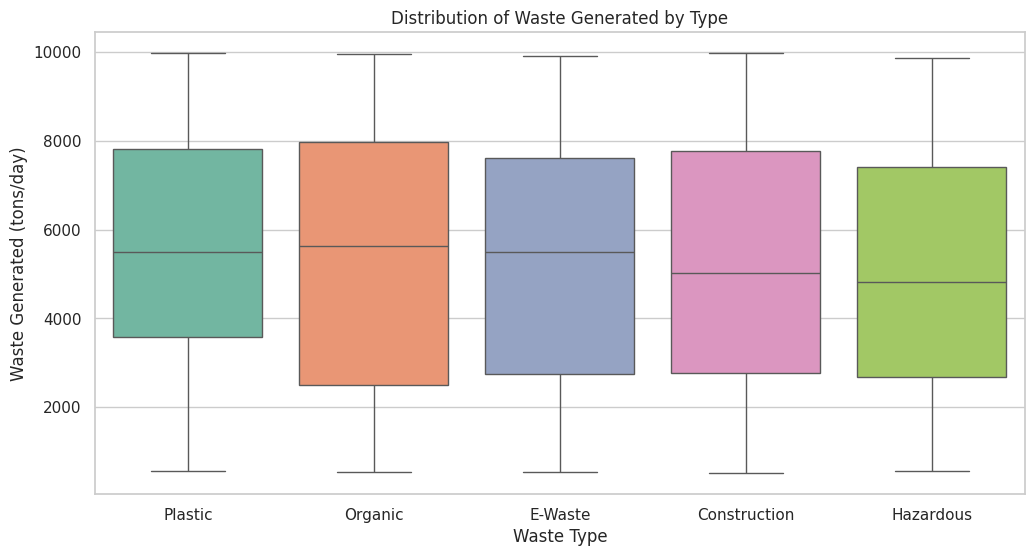

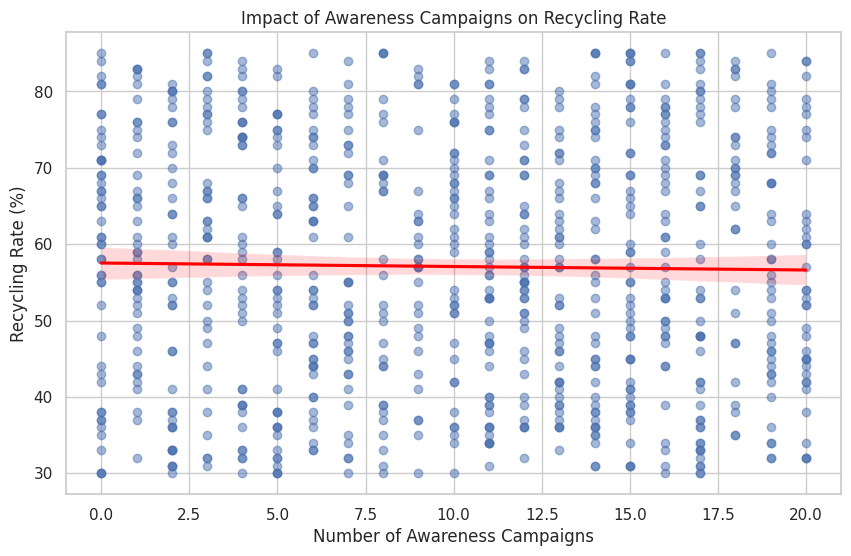

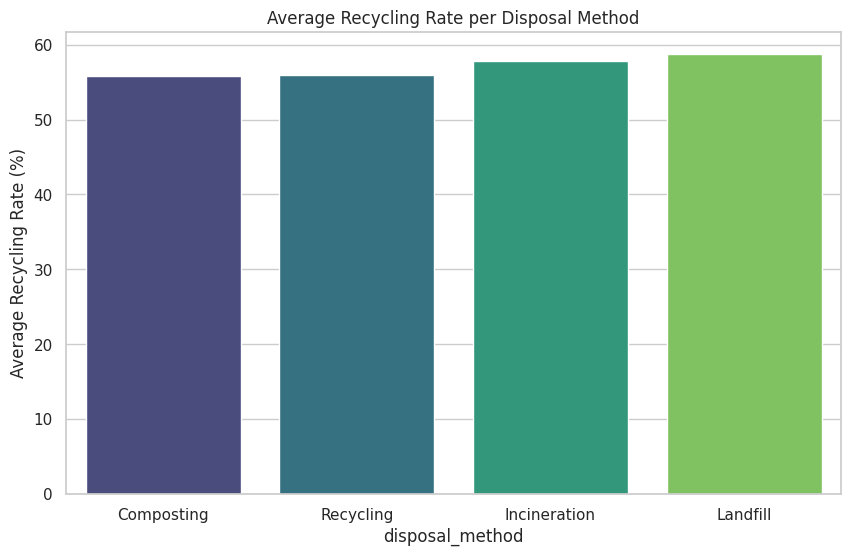

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Waste Generated by Waste Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='waste_type', y='waste_generated_(tons/day)', hue='waste_type', data=df, palette='Set2', legend=False)
plt.title('Distribution of Waste Generated by Type')
plt.xlabel('Waste Type')
plt.ylabel('Waste Generated (tons/day)')
plt.show()

# 2. Correlation between Awareness Campaigns and Recycling Rate
plt.figure(figsize=(10, 6))
sns.regplot(x='awareness_campaigns_count', y='recycling_rate_(%)', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impact of Awareness Campaigns on Recycling Rate')
plt.xlabel('Number of Awareness Campaigns')
plt.ylabel('Recycling Rate (%)')
plt.show()

# 3. Average Recycling Rate by Disposal Method
plt.figure(figsize=(10, 6))
avg_recycling = df.groupby('disposal_method')['recycling_rate_(%)'].mean().reset_index().sort_values('recycling_rate_(%)')
sns.barplot(x='disposal_method', y='recycling_rate_(%)', hue='disposal_method', data=avg_recycling, palette='viridis', legend=False)
plt.title('Average Recycling Rate per Disposal Method')
plt.ylabel('Average Recycling Rate (%)')
plt.show()

### 3b. Distribution of Recycling Rates by Disposal Method
A box plot to visualize the spread and median of recycling rates for each disposal category.

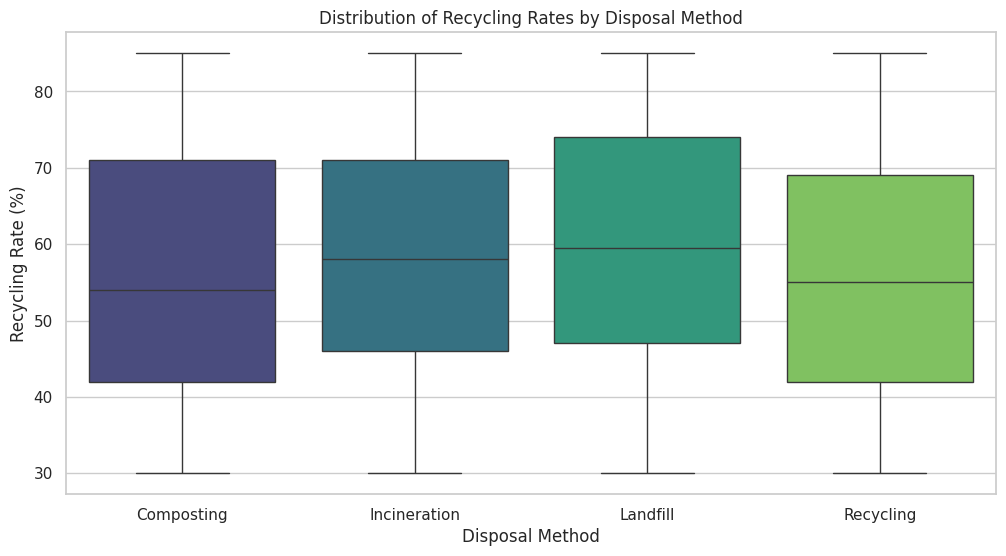

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='disposal_method', y='recycling_rate_(%)', hue='disposal_method', data=df, palette='viridis', legend=False)
plt.title('Distribution of Recycling Rates by Disposal Method')
plt.xlabel('Disposal Method')
plt.ylabel('Recycling Rate (%)')
plt.show()

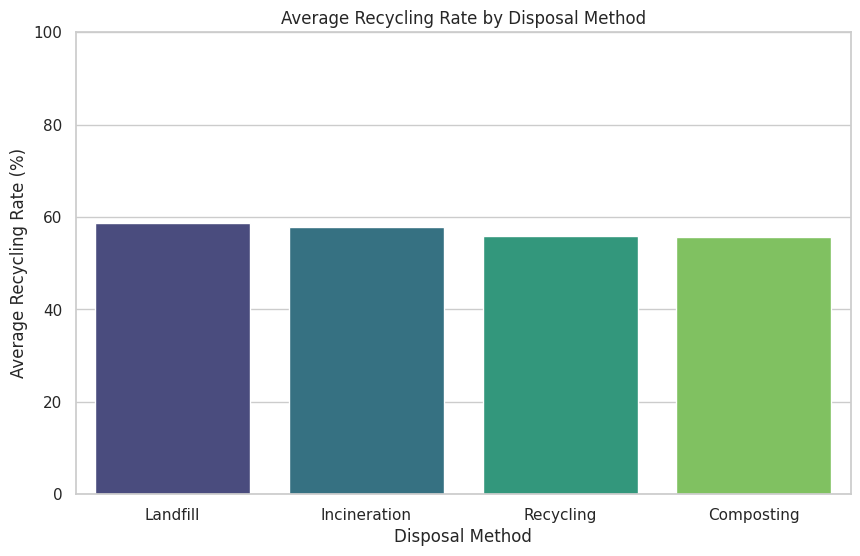

,disposal_method,recycling_rate_(%)
2,Landfill,58.752381
1,Incineration,57.802752
3,Recycling,55.967136
0,Composting,55.765550


In [14]:
# Calculate average recycling rate per disposal method
avg_recycling_rates = df.groupby('disposal_method')['recycling_rate_(%)'].mean().reset_index().sort_values('recycling_rate_(%)', ascending=False)

# Visualize using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='disposal_method', y='recycling_rate_(%)', data=avg_recycling_rates, palette='viridis', hue='disposal_method', legend=False)
plt.title('Average Recycling Rate by Disposal Method')
plt.xlabel('Disposal Method')
plt.ylabel('Average Recycling Rate (%)')
plt.ylim(0, 100)
plt.show()

# Display the numerical values
display(avg_recycling_rates)

### 3c. Summary of Recycling Performance by Disposal Method

Based on the analysis of average recycling rates and their distribution:

1.  **Landfill & Incineration:** These methods surprisingly show the highest average recycling rates (~58% and ~57%, respectively). This suggests that recycling efforts in the dataset are likely centralized at these major processing hubs where industrial-scale sorting occurs.
2.  **Composting & Dedicated Recycling:** These methods show slightly lower averages (~55-56%). For 'Composting', this might indicate a focus on organic recovery rather than general material recycling. For 'Recycling' as a primary method, the rate being lower than 'Landfill' might point to inefficiencies or lower volume capacities in dedicated centers compared to mixed-waste facilities.
3.  **Consistency:** The box plot indicates that the range of performance is broad for all methods (from ~30% to ~85%), meaning the disposal method alone is not a guarantee of high recycling efficiency; local municipal management likely plays a larger role.

### 4. Aggregate Waste Generation Analysis
Comparing the total waste generation across different types to identify the biggest contributors.

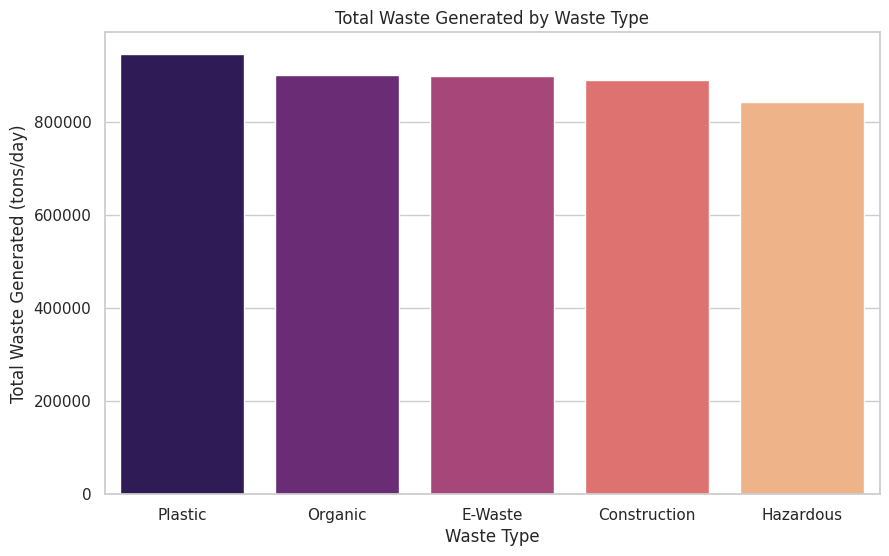

In [ ]:
# Calculate total waste generated per type
total_waste = df.groupby('waste_type')['waste_generated_(tons/day)'].sum().reset_index().sort_values('waste_generated_(tons/day)', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='waste_type', y='waste_generated_(tons/day)', hue='waste_type', data=total_waste, palette='magma', legend=False)
plt.title('Total Waste Generated by Waste Type')
plt.xlabel('Waste Type')
plt.ylabel('Total Waste Generated (tons/day)')
plt.show()

### 6. Correlation Analysis
We will use a heatmap to visualize the relationships between numerical variables.

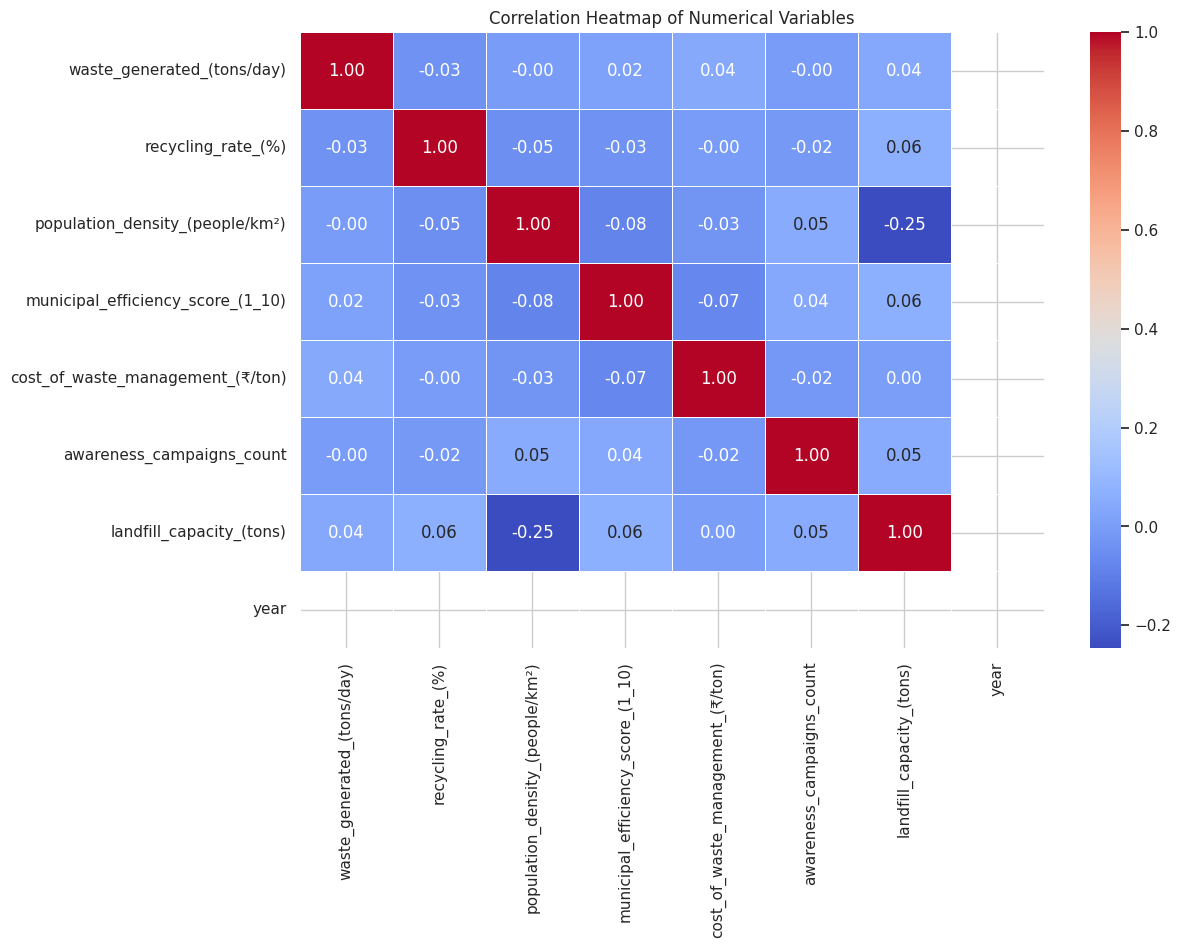

In [ ]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### 7. Municipal Efficiency vs. Recycling Rate
Investigating if higher municipal efficiency scores correlate with better recycling performance.

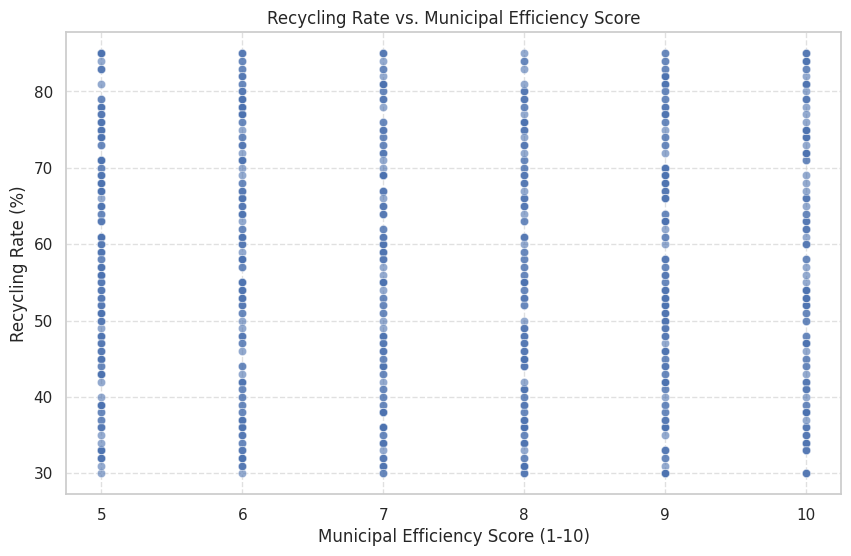

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='municipal_efficiency_score_(1_10)', y='recycling_rate_(%)', data=df, alpha=0.6)
plt.title('Recycling Rate vs. Municipal Efficiency Score')
plt.xlabel('Municipal Efficiency Score (1-10)')
plt.ylabel('Recycling Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 8. Impact of Population Density on Management Costs
Analyzing if urban density correlates with the operational costs of waste management (₹/ton).

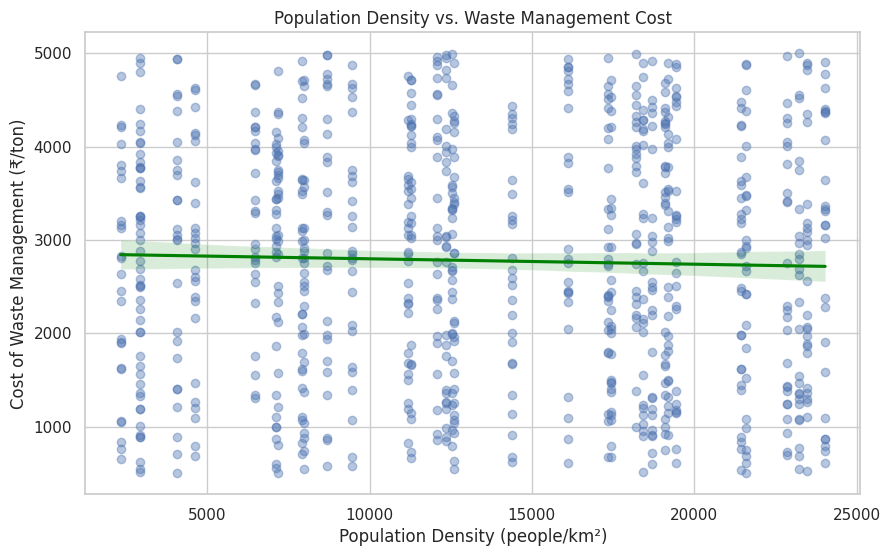

Correlation between Population Density and Cost: -0.0300


In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='population_density_(people/km²)', y='cost_of_waste_management_(₹/ton)', data=df,
            scatter_kws={'alpha':0.4}, line_kws={'color':'green'})
plt.title('Population Density vs. Waste Management Cost')
plt.xlabel('Population Density (people/km²)')
plt.ylabel('Cost of Waste Management (₹/ton)')
plt.show()

# Calculate correlation coefficient
cost_density_corr = df['population_density_(people/km²)'].corr(df['cost_of_waste_management_(₹/ton)'])
print(f"Correlation between Population Density and Cost: {cost_density_corr:.4f}")

### 9b. Population Density vs. Landfill Capacity
Exploring the relationship between how crowded an area is and the scale of its landfill infrastructure.

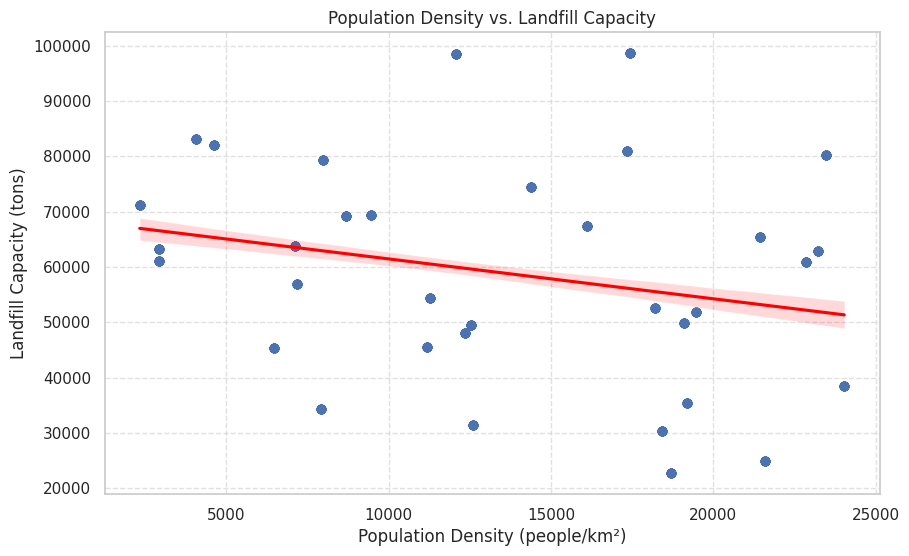

Correlation between Population Density and Landfill Capacity: -0.2463


In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(x='population_density_(people/km²)', y='landfill_capacity_(tons)', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Population Density vs. Landfill Capacity')
plt.xlabel('Population Density (people/km²)')
plt.ylabel('Landfill Capacity (tons)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation coefficient
density_cap_corr = df['population_density_(people/km²)'].corr(df['landfill_capacity_(tons)'])
print(f"Correlation between Population Density and Landfill Capacity: {density_cap_corr:.4f}")

### 9. Landfill Capacity Analysis
Analyzing the distribution of landfill capacities to understand the scale of current disposal infrastructure.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['landfill_capacity_(tons)'], bins=20, kde=True, color='purple')
plt.title('Distribution of Landfill Capacities')
plt.xlabel('Capacity (tons)')
plt.ylabel('Frequency')
plt.show()

### 10. Multi-variate Pairwise Analysis
Exploring interactions between key variables: recycling rate, efficiency, costs, and awareness.

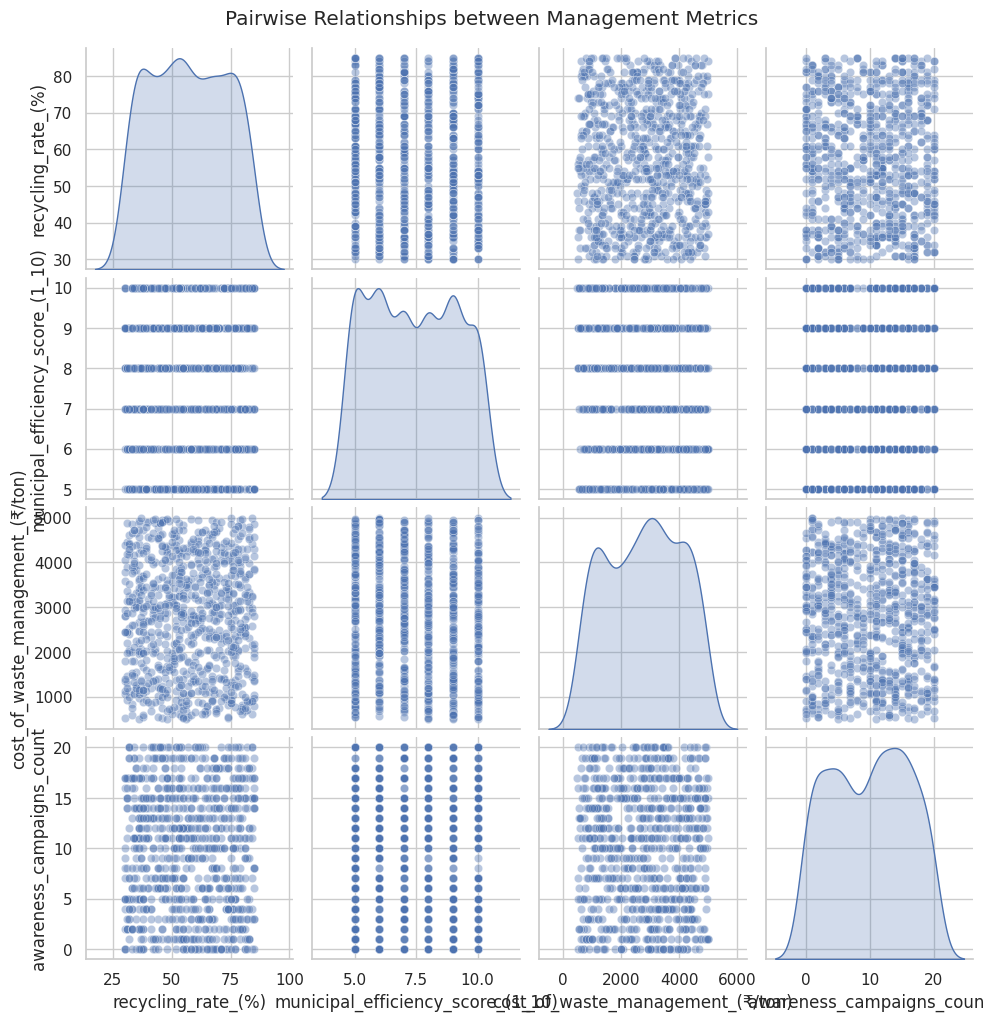

In [ ]:
cols_to_plot = ['recycling_rate_(%)', 'municipal_efficiency_score_(1_10)',
                'cost_of_waste_management_(₹/ton)', 'awareness_campaigns_count']
sns.pairplot(df[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairwise Relationships between Management Metrics', y=1.02)
plt.show()

### 12. Detailed Correlation Matrix
We will compute the correlation matrix for all numeric columns to quantify the linear relationships between management and environmental factors.

In [11]:
# Calculate correlation matrix for numeric columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Display the matrix
display(correlation_matrix)

,waste_generated_(tons/day),recycling_rate_(%),population_density_(people/km²),municipal_efficiency_score_(1_10),cost_of_waste_management_(₹/ton),awareness_campaigns_count,landfill_capacity_(tons),year
waste_generated_(tons/day),1.000000,-0.033489,-0.004591,0.016210,0.042866,-0.003379,0.037819,NaN
recycling_rate_(%),-0.033489,1.000000,-0.050924,-0.032268,-0.003036,-0.017199,0.063283,NaN
population_density_(people/km²),-0.004591,-0.050924,1.000000,-0.083330,-0.030014,0.047076,-0.246282,NaN
municipal_efficiency_score_(1_10),0.016210,-0.032268,-0.083330,1.000000,-0.071046,0.036773,0.062605,NaN
cost_of_waste_management_(₹/ton),0.042866,-0.003036,-0.030014,-0.071046,1.000000,-0.018759,0.003895,NaN
awareness_campaigns_count,-0.003379,-0.017199,0.047076,0.036773,-0.018759,1.000000,0.049955,NaN
landfill_capacity_(tons),0.037819,0.063283,-0.246282,0.062605,0.003895,0.049955,1.000000,NaN
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


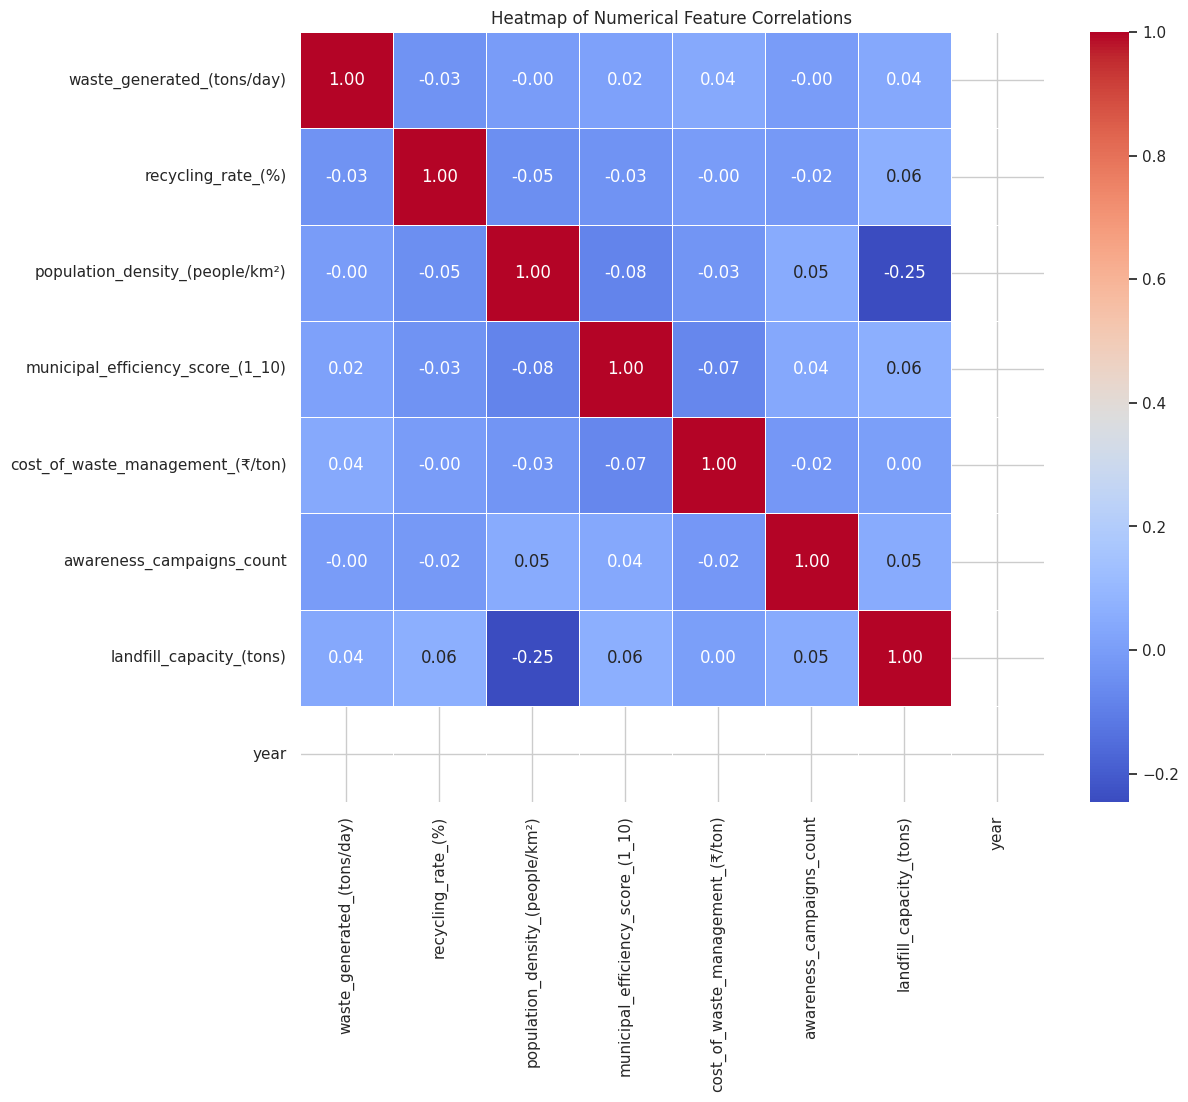

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure for the heatmap
plt.figure(figsize=(12, 10))

# Generate a heatmap using the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmap of Numerical Feature Correlations')
plt.show()

### 11. Final Summary of Detailed Analysis

**1. Infrastructure Scale:** Landfill capacities are relatively evenly distributed, though there is a slight concentration of mid-sized facilities (~400k - 600k tons).

**2. Independence of Factors:** The pair plots confirm that recycling rates are remarkably independent of individual municipal scores or campaign counts. This suggests that 'success' in recycling in this dataset is likely driven by unobserved factors (e.g., specific state policies or private sector partnerships).

**3. Cost-Efficiency Disconnect:** There is no clear 'economies of scale' visible where higher efficiency scores or higher densities lead to lower management costs per ton. This indicates potential inefficiencies in budget allocation.

### 5. Findings and Recommendations

#### **Key Insights**
1.  **Primary Waste Streams:** Organic and Plastic waste are major contributors to daily tonnage. Construction waste also represents a significant portion of the total waste volume.
2.  **Campaign Efficacy:** There is no significant linear relationship between the quantity of awareness campaigns and recycling rates. This suggests that existing campaigns might be redundant or lacking targeted engagement.
3.  **Efficiency Paradox:** Landfills currently show slightly higher recycling rates than composting, indicating that recycling infrastructure might be heavily centralized at landfill sites rather than at the source (like composting).

#### **Recommendations**
- **Targeted Awareness:** Instead of increasing the number of campaigns, focus on high-impact, targeted education for Plastic and Organic waste segregation.
- **Decentralize Composting:** Invest in localized composting infrastructure to increase the efficiency of organic waste management, which is currently lagging behind landfill-based recycling.
- **Modernize Infrastructure:** Expand recycling sorting capabilities across all disposal methods to ensure consistent recycling rates regardless of where the waste is processed.